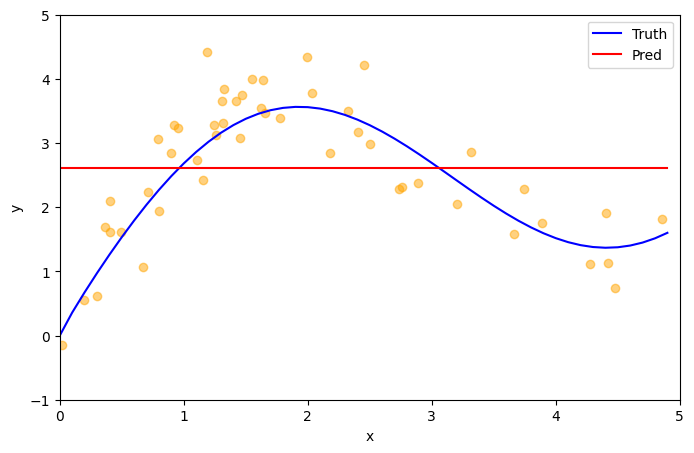

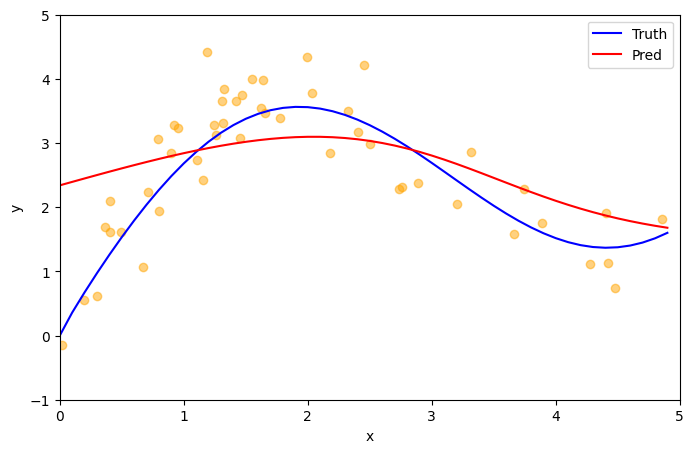

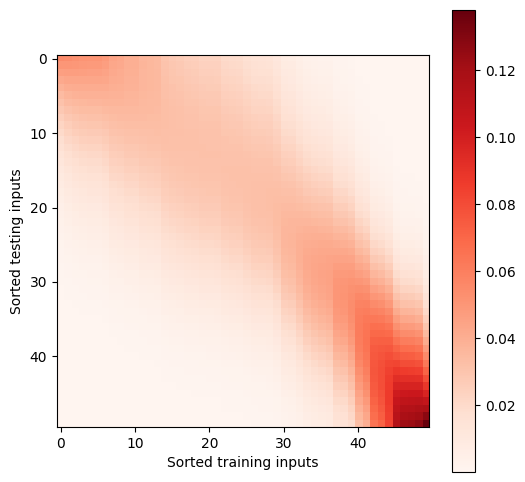

bmm结果形状: torch.Size([2, 1, 6])
权重-值bmm结果: tensor([[[ 4.5000]],

        [[14.5000]]])
epoch 1, loss 51.183838
epoch 2, loss 20.584543
epoch 3, loss 20.525303
epoch 4, loss 20.466244
epoch 5, loss 20.407383


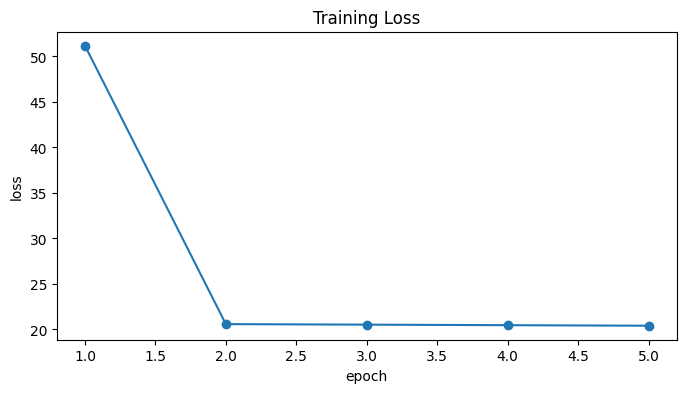

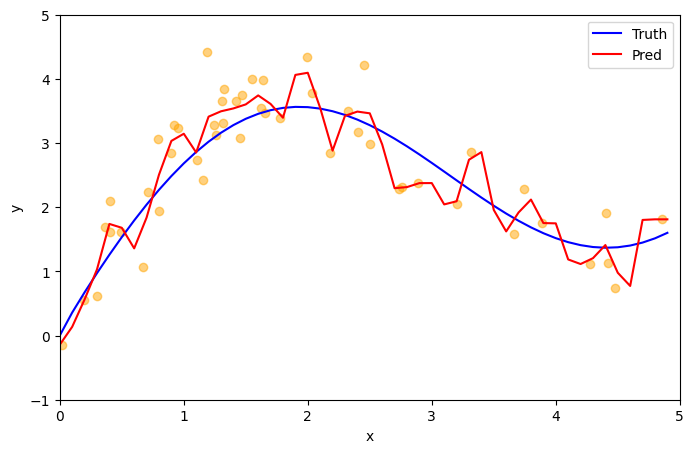

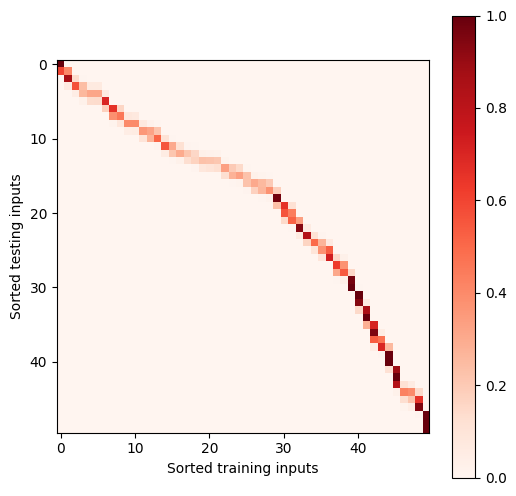

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

# ====================== 1. 数据生成 ======================
n_train = 50  # 训练样本数
x_train, _ = torch.sort(torch.rand(n_train) * 5)  # 排序后的训练样本

def f(x):
    return 2 * torch.sin(x) + x**0.8

# 训练样本（加噪声）和测试样本
y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))  # 带噪声的训练输出
x_test = torch.arange(0, 5, 0.1)  # 测试样本
y_truth = f(x_test)  # 测试样本的真实输出
n_test = len(x_test)  # 测试样本数

# ====================== 2. 绘图函数（替代d2l.plot） ======================
def plot_kernel_reg(y_hat):
    plt.figure(figsize=(8, 5))
    # 绘制真实值和预测值
    plt.plot(x_test.numpy(), y_truth.numpy(), label='Truth', color='blue')
    plt.plot(x_test.numpy(), y_hat.numpy(), label='Pred', color='red')
    # 绘制训练样本点
    plt.scatter(x_train.numpy(), y_train.numpy(), alpha=0.5, color='orange')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim([0, 5])
    plt.ylim([-1, 5])
    plt.legend()
    plt.show()

# ====================== 3. 基础均值预测（基准模型） ======================
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

# ====================== 4. 核回归（非参数注意力版） ======================
# X_repeat: (n_test, n_train)，每行都是相同的测试输入（查询）
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
# 注意力权重：高斯核计算相似度，softmax归一化
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)
# 加权平均计算预测值（注意力加权）
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)

# 绘制注意力权重热力图（替代d2l.show_heatmaps）
plt.figure(figsize=(6, 6))
plt.imshow(attention_weights.numpy(), cmap='Reds')
plt.xlabel('Sorted training inputs')
plt.ylabel('Sorted testing inputs')
plt.colorbar()
plt.show()

# ====================== 5. 批量矩阵乘法示例（原代码中的验证） ======================
X = torch.ones((2, 1, 4))
Y = torch.ones((2, 4, 6))
print("bmm结果形状:", torch.bmm(X, Y).shape)  # 输出: torch.Size([2, 1, 6])

weights = torch.ones((2, 10)) * 0.1
values = torch.arange(20.0).reshape((2, 10))
print("权重-值bmm结果:", torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1)))

# ====================== 6. 带可学习参数的核回归模型 ======================
class NWKernelRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))  # 可学习的带宽参数

    def forward(self, queries, keys, values):
        # queries: (查询数,) -> 扩展为 (查询数, 键值对个数)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        # 计算注意力权重（带可学习带宽w）
        self.attention_weights = nn.functional.softmax(
            -((queries - keys) * self.w)**2 / 2, dim=1)
        # 加权求和: (查询数, 1, 键值对个数) @ (查询数, 键值对个数, 1) -> (查询数, 1)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)

# 构建训练用的键和值（留一法：每个样本作为查询时，排除自身）
# X_tile: (n_train, n_train) 每行都是相同的训练输入
X_tile = x_train.repeat((n_train, 1))
Y_tile = y_train.repeat((n_train, 1))
# 生成掩码：排除对角线（自身）
mask = 1 - torch.eye(n_train)
keys = X_tile[mask.bool()].reshape((n_train, -1))  # (n_train, n_train-1)
values = Y_tile[mask.bool()].reshape((n_train, -1))  # (n_train, n_train-1)

# ====================== 7. 模型训练 ======================
net = NWKernelRegression()
loss_fn = nn.MSELoss(reduction='none')
optimizer = torch.optim.SGD(net.parameters(), lr=0.5)

# 训练过程（替代d2l.Animator，打印loss并绘图）
loss_history = []
for epoch in range(5):
    optimizer.zero_grad()
    # 前向传播
    y_pred = net(x_train, keys, values)
    # 计算损失
    loss = loss_fn(y_pred, y_train)
    loss_sum = loss.sum()
    # 反向传播+优化
    loss_sum.backward()
    optimizer.step()
    # 记录损失
    loss_history.append(loss_sum.item())
    print(f'epoch {epoch + 1}, loss {loss_sum.item():.6f}')

# 绘制训练损失
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), loss_history, marker='o')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training Loss')
plt.show()

# ====================== 8. 模型预测与可视化 ======================
# 构建测试用的键和值（所有训练样本作为键值对）
keys_test = x_train.repeat((n_test, 1))  # (n_test, n_train)
values_test = y_train.repeat((n_test, 1))  # (n_test, n_train)

# 预测（关闭梯度计算）
with torch.no_grad():
    y_hat = net(x_test, keys_test, values_test).unsqueeze(1)

# 绘制预测结果
plot_kernel_reg(y_hat)

# 绘制训练后的注意力权重热力图
plt.figure(figsize=(6, 6))
plt.imshow(net.attention_weights.numpy(), cmap='Reds')
plt.xlabel('Sorted training inputs')
plt.ylabel('Sorted testing inputs')
plt.colorbar()
plt.show()